- support vector machine = 1950 (optimización)

- Random Forest = 1999-2000 (conjunto de arboles de decisiòn) , todos en general sufren de sobreajuste.  Se adaptan facilmente a cualquier base de datos.

- Gradient Boosting = 2004 ( Random Forest mejorado)

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import pandas as pd

# Cargar datos
data = load_breast_cancer()
X = data.data
y = data.target

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [ ]:

# Normalizar los datos para SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definir rangos de hiperparámetros
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1]
}

# Crear y ejecutar GridSearchCV
grid_search_svm = GridSearchCV(SVC(probability=True, random_state=42), param_grid_svm, cv=5, scoring='accuracy')
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_search_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring='accuracy')

# para SVM tuvimos que usar las variables escaladas
grid_search_svm.fit(X_train_scaled, y_train)

# para los arboles o las florestas no es necesario escalar las variables.
grid_search_rf.fit(X_train, y_train)
grid_search_gb.fit(X_train, y_train)

# Mejores hiperparámetros y modelos
best_svm_par = grid_search_svm.best_params_
best_rf_par = grid_search_rf.best_params_
best_gb_par = grid_search_gb.best_params_

best_svm = grid_search_svm.best_estimator_
best_rf = grid_search_rf.best_estimator_
best_gb = grid_search_gb.best_estimator_

In [ ]:
best_svm_par

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

In [ ]:
best_rf_par

{'max_depth': None, 'n_estimators': 100}

In [ ]:
best_gb_par

{'learning_rate': 0.1, 'n_estimators': 100}

In [ ]:
# Función para evaluar modelos
def evaluate_model(model, X_test, y_test, is_svm=False):
    X = X_test_scaled if is_svm else X_test
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }
    return metrics

# Evaluar modelos
eval_svm = evaluate_model(best_svm, X_test, y_test, is_svm=True)
eval_rf = evaluate_model(best_rf, X_test, y_test)
eval_gb = evaluate_model(best_gb, X_test, y_test)

# Comparación de resultados
results_df = pd.DataFrame([eval_svm, eval_rf, eval_gb], index=["SVM", "Random Forest", "Gradient Boosting"])
results_df


,Accuracy,Recall,Precision,F1 Score,ROC AUC
SVM,0.982456,0.990741,0.981651,0.986175,0.997942
Random Forest,0.970760,0.990741,0.963964,0.977169,0.996840
Gradient Boosting,0.959064,0.972222,0.963303,0.967742,0.995150


## Otro ejemplo

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Cargar los datos
# Asegúrate de tener la URL correcta o el archivo local del conjunto de datos del Titanic
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_data = pd.read_csv(titanic_url)




In [ ]:
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


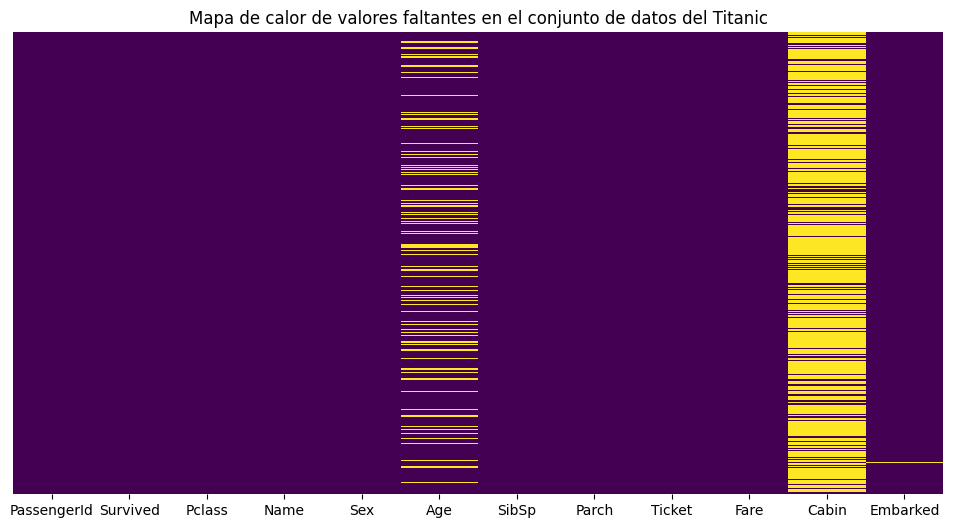

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Visualizar valores perdidos
plt.figure(figsize=(12, 6))
sns.heatmap(titanic_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores faltantes en el conjunto de datos del Titanic')
plt.show()


In [ ]:
# Calcular el número de valores nulos en cada columna
valores_nulos = titanic_data.isnull().sum()

print(valores_nulos)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Calcular el porcentaje de valores nulos en cada columna
porcentaje_nulos = (titanic_data.isnull().sum() / len(titanic_data)) * 100

print(porcentaje_nulos)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [ ]:

# Preparar los datos
X = titanic_data.drop('Survived', axis=1)
y = titanic_data['Survived']

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

# Preprocesamiento de datos
numeric_features = ['Age', 'Fare']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_features = ['Embarked', 'Sex', 'Pclass']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

In [ ]:

# Crear pipeline de clasificación
clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', LogisticRegression())])

In [ ]:
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'Sex',
                                                   'Pclass'])])),
                ('classifier', LogisticRegression())])

In [ ]:


# Entrenar el modelo
clf.fit(X_train, y_train)

# Evaluar el modelo
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       105
           1       0.76      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

